# Section 1: Environment Setup & Global Parameters
Description: Imports essential machine learning libraries (NumPy, Pandas, Matplotlib, Scikit-learn) and defines global configuration variables for the simulation size, number of iterations, and selection constraints.

In [4]:
"""Controlled HR simulation; not evidence about real hiring prevalence or causality."""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score
from sklearn.model_selection import train_test_split

N, RUNS, INTERVIEW_RATE = 1500, 30, 0.30

# Section 2: Synthetic Data Generation Factory 
Description: Defines the data generation process. It creates a controlled synthetic dataset containing demographic attributes, professional features, a true 'Merit' benchmark, and a 'Historical' label injected with artificial bias to act as a stress-test baseline.

In [6]:
def make_data(seed):
    rng = np.random.default_rng(seed)
    gender = rng.integers(0, 2, N)  # simulated group: 0=female, 1=male
    experience = rng.integers(0, 11, N)
    technical = np.clip(rng.normal(70, 10, N), 40, 100)

    # Scenario assumption, not an empirical estimate.
    gap_prob = np.where(gender == 0, 0.45, 0.15)
    career_gap = rng.binomial(1, gap_prob)
    merit_score = 0.7 * technical + 3 * experience + rng.normal(0, 3, N)
    merit_label = (merit_score >= np.quantile(merit_score, 0.70)).astype(int)
    # Deliberately injected bias for a controlled stress test.
    historical_score = merit_score + 8 * gender - 6 * career_gap
    historical_score += rng.normal(0, 3, N)
    historical_label = (
        historical_score >= np.quantile(historical_score, 0.70)
    ).astype(int)
    return pd.DataFrame({
        "Technical_Score": technical, "Experience": experience, "Gender": gender, "Career_Gap": career_gap, "Merit_Label": merit_label, "Historical_Label": historical_label,
    })

df = make_data(42)
df.head()

,Technical_Score,Experience,Gender,Career_Gap,Merit_Label,Historical_Label
0,79.629606,5,0,1,0,0
1,62.753889,2,1,0,0,0
2,61.462408,2,1,0,0,0
3,74.597060,3,0,0,0,0
4,79.885532,6,0,0,1,1


# Section 3: Fairness Metrics & Mitigation Utilities
Description: Contains the operational utility functions. `reweigh` calculates sample weights to counter historical disparity, `select_top` applies a capacity-constrained decision threshold, and `evaluate` tracks both utility and demographic fairness metrics across groups.

In [8]:
def reweigh(df):
    weights = np.ones(len(df))
    for group in [0, 1]:
        for label in [0, 1]:
            mask = (df["Gender"] == group) & (df["Historical_Label"] == label)
            joint = mask.mean()
            if joint > 0:
                weights[mask] = (
                    (df["Gender"] == group).mean()
                    * (df["Historical_Label"] == label).mean()
                    / joint
                )
    return weights 

def select_top(probabilities):
    prediction = np.zeros(len(probabilities), dtype=int)
    n_selected = round(len(probabilities) * INTERVIEW_RATE)
    prediction[np.argsort(probabilities)[-n_selected:]] = 1
    return prediction

def evaluate(df, prediction):
    female = df["Gender"] == 0
    male = ~female
    qualified = df["Merit_Label"] == 1
    female_rate = prediction[female].mean()
    male_rate = prediction[male].mean()
    female_tpr = prediction[female & qualified].mean()
    male_tpr = prediction[male & qualified].mean()
    return {
        "Historical Agreement": accuracy_score(df["Historical_Label"], prediction),
        "Merit Accuracy": accuracy_score(df["Merit_Label"], prediction),
        "Merit Recall": recall_score(df["Merit_Label"], prediction),
        "Female Selection Rate": female_rate,
        "Male Selection Rate": male_rate,
        "Selection Rate Ratio": female_rate / male_rate,
        "Equal Opportunity Gap": female_tpr - male_tpr,
    }

# Quick validation check for sample weights
sample_weights = reweigh(df)
print("Sample weights for the first 5 rows:", sample_weights[:5])

Sample weights for the first 5 rows: [0.861      1.18533333 1.18533333 0.861      1.60434783]


# Section 4: Main Simulation Loop & Model Training
Description: Runs the Monte Carlo simulation across 30 iterations. In each run, it splits the data using stratified sampling, trains four distinct modeling pipelines (Historical, Blind, Reweighted, and Benchmark), and exports the raw experimental logs to CSV files.

In [10]:
records = []

for seed in range(RUNS):
    data = make_data(seed)
    strata = data["Historical_Label"].astype(str) + "_" + data["Gender"].astype(str)
    train, test = train_test_split(
        data, test_size=0.30, random_state=seed, stratify=strata
    )

    model_specs = {
        "Historical Model": (
            ["Technical_Score", "Experience", "Gender", "Career_Gap"],
            "Historical_Label", None
        ),
        "Gender-Blind Model": (
            ["Technical_Score", "Experience", "Career_Gap"],
            "Historical_Label", None
        ),
        "Reweighted Gender-Blind Model": (
            ["Technical_Score", "Experience", "Career_Gap"],
            "Historical_Label", reweigh(train)
        ),
        "Merit Benchmark": (
            ["Technical_Score", "Experience"], "Merit_Label", None
        ),
    }

    for name, (features, target, weights) in model_specs.items():
        model = LogisticRegression(
            max_iter=1000, solver="liblinear", random_state=seed
        )
        model.fit(train[features], train[target], sample_weight=weights)
        probabilities = model.predict_proba(test[features])[:, 1]
        row = evaluate(test, select_top(probabilities))
        row.update({"Run": seed + 1, "Model": name})
        records.append(row)

results = pd.DataFrame(records)

# Save results and display the raw tracking log
summary = results.groupby("Model").agg(["mean", "std"])
summary.to_csv("fair_hiring_summary_revised.csv")
results.to_csv("fair_hiring_all_runs_revised.csv", index=False)

results.head()

,Historical Agreement,Merit Accuracy,Merit Recall,Female Selection Rate,Male Selection Rate,Selection Rate Ratio,Equal Opportunity Gap,Run,Model
0,0.911111,0.842222,0.742424,0.172093,0.417021,0.412672,-0.457143,1,Historical Model
1,0.884444,0.846667,0.750000,0.251163,0.344681,0.728682,-0.228111,1,Gender-Blind Model
2,0.875556,0.864444,0.780303,0.265116,0.331915,0.798748,-0.194009,1,Reweighted Gender-Blind Model
3,0.826667,0.908889,0.856061,0.316279,0.285106,1.109337,0.028111,1,Merit Benchmark
4,0.915556,0.817778,0.693431,0.174107,0.424779,0.409877,-0.471846,2,Historical Model


# Section 5: Aggregated Statistical Performance Table
Description: Groups the tracking log by model architecture and calculates the mean values for all metrics across all 30 simulation runs, sorting the results into a structured evaluation matrix.

In [11]:
order = ["Historical Model", "Gender-Blind Model", "Reweighted Gender-Blind Model", "Merit Benchmark"]
means = results.groupby("Model").mean(numeric_only=True).loc[order]

# Display the aggregated mean summary table
means.round(2)

,Historical Agreement,Merit Accuracy,Merit Recall,Female Selection Rate,Male Selection Rate,Selection Rate Ratio,Equal Opportunity Gap,Run
Model,,,,,,,,
Historical Model,0.90,0.84,0.74,0.17,0.43,0.39,-0.44,15.5
Gender-Blind Model,0.87,0.87,0.78,0.26,0.34,0.79,-0.16,15.5
Reweighted Gender-Blind Model,0.87,0.88,0.80,0.27,0.33,0.82,-0.13,15.5
Merit Benchmark,0.84,0.91,0.86,0.30,0.30,1.04,0.00,15.5


# Section 6: Visualization - Predictive Performance & Talent Identification
Description: Plots and saves a comparative bar chart displaying the mean 'Merit Accuracy' and 'Merit Recall' for each model to visualize their effective utility in identifying qualified talent.

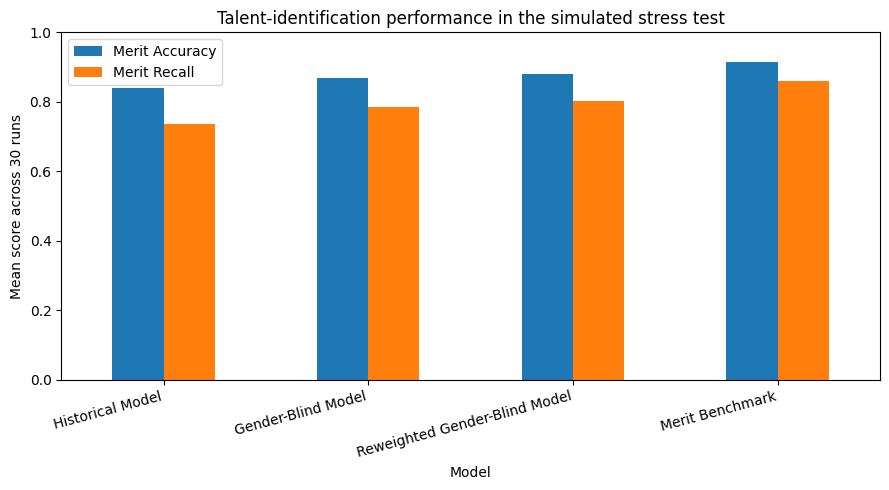

In [13]:
means[["Merit Accuracy", "Merit Recall"]].plot(kind="bar", figsize=(9, 5))
plt.ylim(0, 1)
plt.ylabel("Mean score across 30 runs")
plt.title("Talent-identification performance in the simulated stress test")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

# Save and display the visualization

plt.savefig("fair_hiring_utility_revised.png", dpi=250)
plt.show()

# Section 7: Visualization - Demographic Selection Rates & Selection Ratios
Description: Generates and saves a bar chart comparing the selection rates between male and female demographic groups across all four simulated models to audit systemic bias and mitigation success.

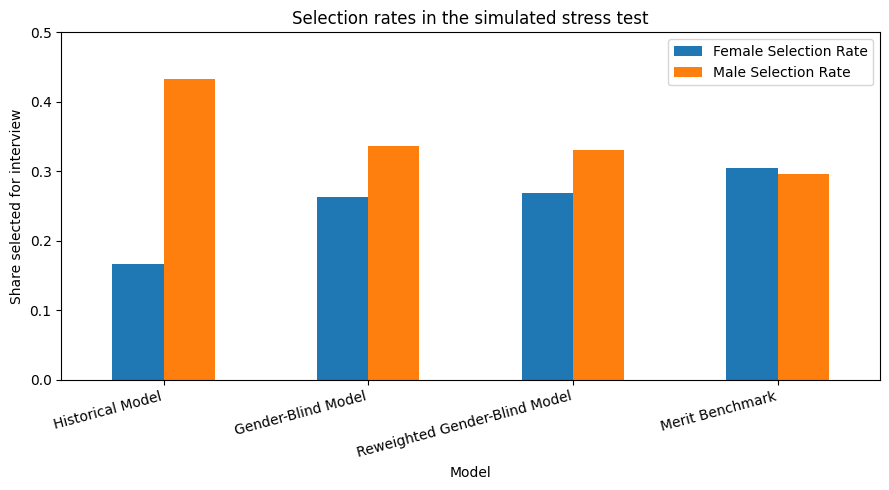

In [14]:
means[["Female Selection Rate", "Male Selection Rate"]].plot(kind="bar", figsize=(9, 5))
plt.ylim(0, 0.50)
plt.ylabel("Share selected for interview")
plt.title("Selection rates in the simulated stress test")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

# Save and display the visualization

plt.savefig("fair_hiring_selection_rates_revised.png", dpi=250)
plt.show()

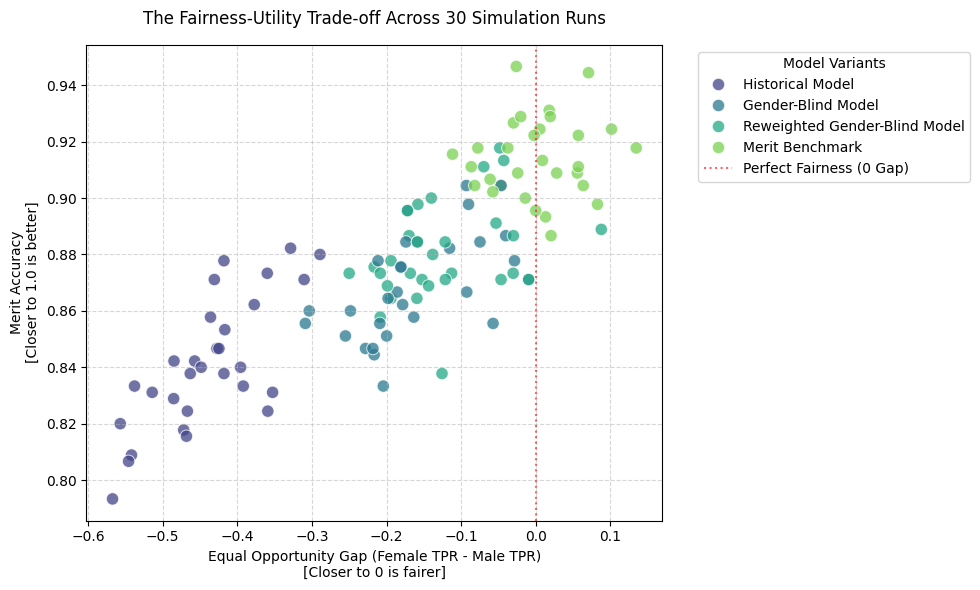

In [15]:
import seaborn as sns

plt.figure(figsize=(10, 6))
# Using Seaborn for a modern, publication-ready look
sns.scatterplot(
    x="Equal Opportunity Gap", 
    y="Merit Accuracy", 
    hue="Model", 
    data=results, 
    palette="viridis", 
    s=80, 
    alpha=0.75
)

# Visual anchors: Ideal target is 0 gap and 1.0 accuracy
plt.axvline(0, color="red", linestyle=":", alpha=0.6, label="Perfect Fairness (0 Gap)")
plt.title("The Fairness-Utility Trade-off Across 30 Simulation Runs", fontsize=12, pad=15)
plt.xlabel("Equal Opportunity Gap (Female TPR - Male TPR)\n[Closer to 0 is fairer]", fontsize=10)
plt.ylabel("Merit Accuracy\n[Closer to 1.0 is better]", fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Model Variants")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("fair_hiring_tradeoff_curve.png", dpi=250)
plt.show()